# Part 1: Learn the language of Clifford + T

In [1]:
from typing import Any

from kirin.ir import Method
import matplotlib.pyplot as plt
import numpy as np

from bloqade import squin, tsim, stim
from bloqade.cirq_utils import emit_circuit, load_circuit, noise
from bloqade.pyqrack import StackMemorySimulator
from bloqade.types import MeasurementResult, Qubit
from kirin.dialects.ilist import IList
import matplotlib.pyplot as plt

# this will help us have return types for our methods that have more intuitive names
Register = IList[Qubit, Any]
Measurement = IList[MeasurementResult, Any]

# this function will help us visualize some circuits
def show_circuit(squin_kernel):
    @squin.kernel
    def _to_visualize():
        _ = squin_kernel()

    return tsim.Circuit(_to_visualize).diagram(height=400)

Simple examples

In [32]:
#1-qubit-gate
@squin.kernel
def Hadamard():
    qubits = squin.qalloc(1)
    squin.h(qubits[0])
    return qubits

display(show_circuit(Hadamard))

#2-qubits-gate
@squin.kernel
def Bell():
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    return qubits

display(show_circuit(Bell))

#ACTION OF GATES ON STATES
@squin.kernel
def Clifford():
    qubits = squin.qalloc(2)
    squin.h(qubits[0])
    squin.cx(qubits[0], qubits[1])
    squin.s(qubits[0])
    squin.s(qubits[1])
    return qubits

display(show_circuit(Clifford))

Clifford single qubit gates (H,S) move the state only in the vertices of Bloch Sphere, so they cannot reproduce on their own all gates. That is why Clifford gates are so important.

# Part 2: Synthesize the rotation family

We attempt to perform using only Clifford gates (and T) any $R_z(\pi/2^n$). 

The cases $n=0$, $n=1$ and $n=2$ are trivial. However, for $n=3,4,5$,... there is no exact solution. We use an approximation method by trial and error, attempting to minimize the distance between operators $U_{exact}$ and $U_{approx}$.

In [36]:
# 1. DEFINICIÓN DE LAS PUERTAS BASE (Nuestras piezas de Lego)
H = (1 / np.sqrt(2)) * np.array([[1, 1], [1, -1]], dtype=complex)

S = np.array([[1, 0], [0, 1j]], dtype=complex)

T = np.array([[1, 0], [0, np.exp(1j * np.pi / 4)]], dtype=complex)

# 2. FUNCIONES OBJETIVO Y MÉTRICA
def target_rz(n):
    theta = np.pi / (2**n)
    return np.array([[np.exp(-1j * theta / 2), 0],
                     [0, np.exp(1j * theta / 2)]], dtype=complex)

def distance_metric(U, V):
    trace_val = np.trace(U.conj().T @ V)
    return np.sqrt(np.clip(1 - np.abs(trace_val) / 2, 0, 1))

    # 1. Caso n=0: Rz(pi) es equivalente a la puerta Z (S @ S)
U0 = target_rz(0)
V0 = S @ S
dist0 = distance_metric(U0, V0)

# 2. Caso n=1: Rz(pi/2) is equiv to S
U1 = target_rz(1)
V1 = S
dist1 = distance_metric(U1, V1)

# 3. Case n=2: Rz(pi/4) is equiv to T
U2 = target_rz(2)
V2 = T
dist2 = distance_metric(U2, V2)

print(f"Distance for n=0 (Rz(pi) vs S*S): {dist0:.2e}")
print(f"Distance for n=1 (Rz(pi/2) vs S):  {dist1:.2e}")
print(f"Distance for n=2 (Rz(pi/4) vs T):  {dist2:.2e}")

Distance for n=0 (Rz(pi) vs S*S): 0.00e+00
Distance for n=1 (Rz(pi/2) vs S):  0.00e+00
Distance for n=2 (Rz(pi/4) vs T):  0.00e+00


In [37]:
gate_dict = {'H': H, 'T': T} 

# 3. GENERADOR DE SUFIJOS (Máximo 3 'T')
def generar_sufijos_validos(longitud_restante, ultima_puerta, consecutivas_t, sufijo_actual=None):
    if sufijo_actual is None:
        sufijo_actual = []
        
    if longitud_restante == 0:
        yield sufijo_actual
        return
        
    if ultima_puerta == 'H':
        yield from generar_sufijos_validos(longitud_restante - 1, 'T', 1, sufijo_actual + ['T'])
    else:
        yield from generar_sufijos_validos(longitud_restante - 1, 'H', 0, sufijo_actual + ['H'])
        if consecutivas_t < 3:
            yield from generar_sufijos_validos(longitud_restante - 1, 'T', consecutivas_t + 1, sufijo_actual + ['T'])

# 4. MOTOR AUTOMATIZADO DE VENTANA DESLIZANTE
def busqueda_automatica_por_bloques(n_target, prof_max_total, tamano_bloque):
    U_objetivo = target_rz(n_target)
    
    prefijo_actual = []
    mejor_dist_global = 1.0
    
    print(f"=== INICIANDO AUTO-COMPILADOR CUÁNTICO para n={n_target} ===")
    print(f"Meta de profundidad: {prof_max_total} | Tamaño de radar (bloque): {tamano_bloque}")
    print("Condición de mejora: ESTRICTAMENTE MENOR (sin tolerancia al ruido)")
    print("=" * 60)

    while len(prefijo_actual) < prof_max_total:
        puertas_a_explorar = min(tamano_bloque, prof_max_total - len(prefijo_actual))
        
        V_prefijo = np.eye(2, dtype=complex)
        for puerta in prefijo_actual:
            V_prefijo = gate_dict[puerta] @ V_prefijo
            
        ultima_p = prefijo_actual[-1] if prefijo_actual else None
        t_consec = 0
        if ultima_p == 'T':
            for p in reversed(prefijo_actual):
                if p == 'T': t_consec += 1
                else: break
                
        mejor_sec_bloque = prefijo_actual.copy()
        mejor_dist_bloque = mejor_dist_global
        hubo_mejora = False
        
        print(f"\n--- Escaneando desde profundidad {len(prefijo_actual)} hasta {len(prefijo_actual) + puertas_a_explorar} ---")
        
        for longitud in range(1, puertas_a_explorar + 1):
            for sufijo in generar_sufijos_validos(longitud, ultima_p, t_consec):
                V_actual = V_prefijo
                for puerta in sufijo:
                    V_actual = gate_dict[puerta] @ V_actual
                
                dist = distance_metric(U_objetivo, V_actual)
                
                if dist < mejor_dist_bloque:
                    mejor_dist_bloque = dist
                    mejor_sec_bloque = prefijo_actual + sufijo
                    hubo_mejora = True
                    
        if hubo_mejora:
            print(f"  [+] Nuevo ancla fijado en profundidad {len(mejor_sec_bloque)} | Récord: {mejor_dist_bloque:.15e}")
            # --- NUEVA LÍNEA PARA IMPRIMIR LA SECUENCIA EN CADA ITERACIÓN ---
            print(f"  [>] Secuencia actual: {mejor_sec_bloque}")
            
            prefijo_actual = mejor_sec_bloque
            mejor_dist_global = mejor_dist_bloque
        else:
            print(f"  [!] ATASCO: El radar de {tamano_bloque} puertas no encontró ninguna ruta que mejore el error actual.")
            print(f"  [!] El algoritmo se detiene para evitar bucles inútiles.")
            break
            
    return prefijo_actual, mejor_dist_global

# --- EJECUCIÓN ---
n_problema = 5

profundidad_maxima_absoluta = 350 
tamano_del_bloque = 33             

secuencia_final, error_final = busqueda_automatica_por_bloques(
    n_problema, 
    profundidad_maxima_absoluta, 
    tamano_del_bloque
)

print("\n=== RESUMEN DE COMPILACIÓN ===")
print(f"Profundidad final lograda: {len(secuencia_final)}")
print(f"Distancia mínima d(U,V): {error_final:.15e}")
print(f"Secuencia: {secuencia_final}")

=== INICIANDO AUTO-COMPILADOR CUÁNTICO para n=5 ===
Meta de profundidad: 350 | Tamaño de radar (bloque): 33
Condición de mejora: ESTRICTAMENTE MENOR (sin tolerancia al ruido)

--- Escaneando desde profundidad 0 hasta 33 ---
  [+] Nuevo ancla fijado en profundidad 30 | Récord: 2.226405264917306e-02
  [>] Secuencia actual: ['H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T']

--- Escaneando desde profundidad 30 hasta 63 ---
  [+] Nuevo ancla fijado en profundidad 62 | Récord: 1.314497109916554e-02
  [>] Secuencia actual: ['H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H']

--- Escaneando desde profundidad 62 hasta 95 ---
  [!] ATASCO: El

Some gate sequences form patterns that can simply the lookout and improve performance

In [ ]:
def procesar_secuencia_rapida(secuencia):
    # Unimos la lista en un solo string: "TTTHTH..."
    texto = "".join(secuencia)
    
    # Reemplazamos cada bloque de "TT" por "S"
    texto_procesado = texto.replace("TT", "S")
    
    # Volvemos a convertir el string en una lista de caracteres
    return list(texto_procesado)

# Tu lista original
secuencia_original = ['T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T']

resultado = procesar_secuencia_rapida(secuencia_original)
print(resultado)


n=3
Profundidad final lograda: 204;      
Distancia mínima d(U,V): 4.964294678808196e-03
Secuencia: ['T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T']

N=4
Profundidad final lograda: 152         
Distancia mínima d(U,V): 1.490135703634670e-02
Secuencia: ['H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T']

N=5
Profundidad final lograda: 145		
Distancia mínima d(U,V): 7.379759280038365e-03
Secuencia: ['T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T']

Benchmarking of some obtained combinations:
Has been done by observing the deviation with respect to the |0> state when the approximation is performed, and right after, the exact inverse rotation.

In [40]:
theta = np.pi/8
gate_sequence = ['S', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'S', 'H', 'S', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'T']

@squin.kernel
def rotation_circuit_n3():
    qubits = squin.qalloc(1)
    for gate in ['S', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'S', 'H', 'S', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'T']:
        if gate == 'H':
            squin.h(qubits[0])
        elif gate == 'S':
            squin.s(qubits[0])
        elif gate == 'T':
            squin.t(qubits[0])

    #Inversa de teorica
    squin.rz(-theta, qubits[0])
    m = squin.broadcast.measure(qubits)
    return m

display(show_circuit(rotation_circuit_n3))
pyqrack_target = StackMemorySimulator(min_qubits=1)
task = pyqrack_target.task(rotation_circuit_n3)
batch_results = task.batch_run(shots=100)
batch_results

{(<Measurement.Zero: 0>,): 1.0}

In [38]:
theta = np.pi/16
gate_sequence = ['H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T']

@squin.kernel
def rotation_circuit_n4():
    qubits = squin.qalloc(1)
    for gate in ['H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T']:
        if gate == 'H':
            squin.h(qubits[0])
        elif gate == 'S':
            squin.s(qubits[0])
        elif gate == 'T':
            squin.t(qubits[0])

    #Inversa de teorica
    squin.rz(-theta, qubits[0])
    m = squin.broadcast.measure(qubits)
    return m

#show_circuit(rotation_circuit)
pyqrack_target = StackMemorySimulator(min_qubits=1)
task = pyqrack_target.task(rotation_circuit_n4)
batch_results = task.batch_run(shots=100)
batch_results

{(<Measurement.Zero: 0>,): 1.0}

In [39]:
theta = np.pi/32
gate_sequence = ['T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T']

@squin.kernel
def rotation_circuit_n5():
    qubits = squin.qalloc(1)
    for gate in ['T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'H', 'T', 'T', 'T', 'H', 'T', 'T', 'H', 'T']:
        if gate == 'H':
            squin.h(qubits[0])
        elif gate == 'S':
            squin.s(qubits[0])
        elif gate == 'T':
            squin.t(qubits[0])

    #Inversa de teorica
    squin.rz(-theta, qubits[0])
    m = squin.broadcast.measure(qubits)
    return m

#show_circuit(rotation_circuit)
pyqrack_target = StackMemorySimulator(min_qubits=1)
task = pyqrack_target.task(rotation_circuit_n5)
batch_results = task.batch_run(shots=100)
batch_results

{(<Measurement.Zero: 0>,): 1.0}

# Part 3: Non-Clifford gates are expensive

Now, situation in which no T can be applied to the qubit, but ancilla qubits are allowed.
The optimal way is through a teleportation algorithm, that transfers the T to the original state.

Parameters:
- Number of ancilla qubits = Nº of T in the 1 qubit circuit.
- Number of 2-qubit gates = Nº of CNOTs = Nº of ancilla qubits.
- Circuit depth = Each additional T gate adds a parallel subroutine that needs to be done. In the operations in the main qubit, only 1 2-qubit-gate is added per T. But if we now consider the process to create the |T> magic state, then the complexity is greater, since T gates are not fault tolerant normally. They should be created via purification.
- Feed forward: the more T you employ, you start to be limited by the time to measure the ancilla, which may dominate over the coherence time of the Rydberg atoms.


Circuit to inject the T to the circuit via an ancilla

In [9]:
@squin.kernel
def t_factory(register: Register):
    squin.reset(register[1])
    squin.h(register[1])
    squin.t(register[1])
    squin.cx(register[0], register[1])
    m = squin.measure(register[1])
    if m == 1:
        squin.s(register[0])
    
@squin.kernel
def generated():
    qubits = squin.qalloc(2)
    for gate in ['H', 'S', 'T']:

        if gate == 'H':
            squin.h(qubits[0])

        elif gate == 'S':
            squin.s(qubits[0])

        elif gate == 'T':
            t_factory(qubits)
        
    m = squin.broadcast.measure(qubits)
    return m[0]

pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(generated)

single_shot = task.run()
single_shot


<Measurement.One: 1>

Benchmarking the T-injection (We know that it should perform a $T$ gate, and $T^8=I$)

In [63]:
@squin.kernel
def t_factory_benchmark():
    register = squin.qalloc(2)
    squin.reset(register[1])
    squin.h(register[1])
    squin.t(register[1])
    squin.cx(register[0], register[1])
    m = squin.measure(register[1])
    if m == 1:
        squin.s(register[0])

    #Inversa: agregar 7 T's
    for _ in range(7):
        squin.t(register[0])
    
    m2 = squin.measure(register[0])
    return m2

pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(t_factory_benchmark)
batch_results = task.batch_run(shots=1000)
batch_results

{<Measurement.Zero: 0>: 1.0}

Benchmarking with Rz rotation: now we add, for $n=3$, the injected $T$ gate to the circuit of Part 2. Again, we benchmark against the ideal rotation.

In [65]:
theta = np.pi/8
gate_sequence = ['S', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'T', 'H', 'T', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'T', 'H', 'S', 'T', 'H', 'T', 'H', 'S', 'H', 'S', 'H', 'T', 'H', 'S', 'T', 'H', 'S', 'H', 'S', 'T', 'H', 'S', 'T']

@squin.kernel
def t_factory(register: Register):
    squin.reset(register[1])
    squin.h(register[1])
    squin.t(register[1])
    squin.cx(register[0], register[1])
    m = squin.measure(register[1])
    if m == 1:
        squin.s(register[0])

@squin.kernel
def generated_benchmark():
    qubits = squin.qalloc(2)
    for gate in gate_sequence:

        if gate == 'H':
            squin.h(qubits[0])

        elif gate == 'S':
            squin.s(qubits[0])

        elif gate == 'T':
            t_factory(qubits)
    #Inversa de teorica
    squin.rz(-theta, qubits[0])
    m = squin.broadcast.measure(qubits)
    return m[0]

pyqrack_target = StackMemorySimulator(min_qubits=2)
task = pyqrack_target.task(generated_benchmark)
batch_results = task.batch_run(shots=100)
batch_results

{<Measurement.Zero: 0>: 1.0}

# Part 4: Move from one physical qubit to one logical qubit

Now we are using not logical qubits but physical qubits, which need encoding. First, we create a kernel that implements the circuit for 1 logical qubit in the [7,1,3] code.

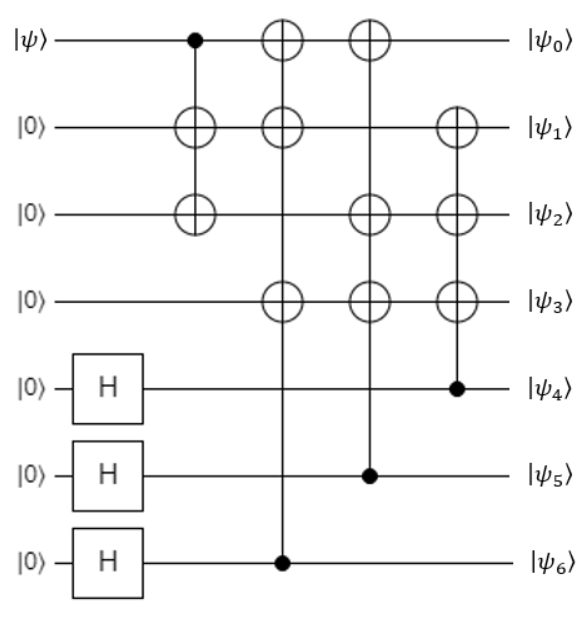

We will benchmark circuits through tomography: measuring all the physical qubits through transversal operations (changing bases with Clifford gates) and determining the parity of the measurement: if it's even, logic 0. If not, logic 1.

In [3]:
def analyze_measurements(raw_results):
    clean_results = {}
    expected_value = 0.0
    
    # Contadores extra para ver la distribución
    prob_logical_0 = 0.0
    prob_logical_1 = 0.0

    for state_tuple, prob in raw_results.items():
        # 1. Extraer los bits y crear un string limpio
        bit_string = ""
        for bit in state_tuple:
            # Si es un objeto Enum, cogemos su valor (.value)
            if hasattr(bit, 'value'):
                bit_string += str(bit.value)
            else:
                # Fallback por si lo copiaste como string literal
                bit_string += str(bit).replace('>', '').split(': ')[-1]
                
        clean_results[bit_string] = prob

        # 2. Calcular la paridad (contar los '1')
        num_ones = bit_string.count('1')
        
        # 3. Asignar el eigenvalor y sumar probabilidades
        if num_ones % 2 == 0:
            eigenvalue = 1  # Paridad par -> Lógico 0
            prob_logical_0 += prob
        else:
            eigenvalue = -1 # Paridad impar -> Lógico 1
            prob_logical_1 += prob

        # 4. Acumular el valor esperado Z
        expected_value += prob * eigenvalue

    # Imprimir un pequeño resumen por consola
    print("--- Análisis de Tomografía Lógica ---")
    print(f"Probabilidad de |0_L> (Paridad Par):   {prob_logical_0:.4f}")
    print(f"Probabilidad de |1_L> (Paridad Impar): {prob_logical_1:.4f}")
    print(f"Valor esperado <Sigma>:                  {expected_value:.4f}\n")
    
    return clean_results, expected_value

Function to encode an arbitrary state with [7,1,3]

In [4]:
#Mi data qubit son los primeros 7 0-6
#Mi ancilla qubit son del 7 al 14 (0-13)

@squin.kernel
def initial_state() -> Register:
    qubits = squin.qalloc(14)
    #1. Preparar el estado fisico psi en el qubit 0.
    #Las operaciones que hagan falta

    # Aplicar el encoding entre los qubits 0 y 6 para preparar el estado logico |psi_L>
    #2. 3 H en el 4,5,6
    squin.h(qubits[4])
    squin.h(qubits[5])
    squin.h(qubits[6])
    #3. CNOTs entre el 0 y 1,2
    squin.cx(qubits[0], qubits[1])
    squin.cx(qubits[0], qubits[2])
    #4. CNOTs entre el de 6 y  0,1 y 3
    squin.cx(qubits[6], qubits[0])
    squin.cx(qubits[6], qubits[1])
    squin.cx(qubits[6], qubits[3])
    #5. CNOTs entre el 5 y los 0,2 y 3
    squin.cx(qubits[5], qubits[0])
    squin.cx(qubits[5], qubits[2])
    squin.cx(qubits[5], qubits[3])
    #6. CNOTs entre el 4 y los 1,2,3
    squin.cx(qubits[4], qubits[1])
    squin.cx(qubits[4], qubits[2])
    squin.cx(qubits[4], qubits[3])
    return qubits


Benchmark this encoder circuit using tomography (|0> is encoded)

In [27]:
#Z
@squin.kernel
def initial_state_with_Z_measurement():
    qubits = squin.qalloc(7)
    squin.h(qubits[4])
    squin.h(qubits[5])
    squin.h(qubits[6])
    #3. CNOTs entre el 0 y 1,2
    squin.cx(qubits[0], qubits[1])
    squin.cx(qubits[0], qubits[2])
    #4. CNOTs entre el de 6 y  0,1 y 3
    squin.cx(qubits[6], qubits[0])
    squin.cx(qubits[6], qubits[1])
    squin.cx(qubits[6], qubits[3])
    #5. CNOTs entre el 5 y los 0,2 y 3
    squin.cx(qubits[5], qubits[0])
    squin.cx(qubits[5], qubits[2])
    squin.cx(qubits[5], qubits[3])
    #6. CNOTs entre el 4 y los 1,2,3
    squin.cx(qubits[4], qubits[1])
    squin.cx(qubits[4], qubits[2])
    squin.cx(qubits[4], qubits[3])
    m = squin.broadcast.measure(qubits)
    return m

Nshots = 1000
pyqrack_target = StackMemorySimulator(min_qubits=7)
task = pyqrack_target.task(initial_state_with_Z_measurement)
batch_results_z = task.batch_run(shots=Nshots)
clean_data_z, z_expected = analyze_measurements(batch_results_z)

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   1.0000
Probabilidad de |1_L> (Paridad Impar): 0.0000
Valor esperado <Sigma>:                  1.0000



Benchmarkear solo el T logico

In [4]:
#Hay que hacer tomografia para ver los valores esperados de X, Y y Z en los 7 primeros qubits para verificar que el estado logico se preparo correctamente.
@squin.kernel
def T_state_Z():
    qubits = squin.qalloc(7)
    #1. Preparar el estado fisico T en el qubit 0.
    #Las operaciones que hagan falta
    squin.h(qubits[0])
    squin.t(qubits[0])
    # Aplicar el encoding entre los qubits 0 y 6 para preparar el estado logico |T_L>
    #2. 3 H en el 4,5,6
    squin.h(qubits[4])
    squin.h(qubits[5])
    squin.h(qubits[6])
    #3. CNOTs entre el 0 y 1,2
    squin.cx(qubits[0], qubits[1])
    squin.cx(qubits[0], qubits[2])
    #4. CNOTs entre el de 6 y  0,1 y 3
    squin.cx(qubits[6], qubits[0])
    squin.cx(qubits[6], qubits[1])
    squin.cx(qubits[6], qubits[3])
    #5. CNOTs entre el 5 y los 0,2 y 3
    squin.cx(qubits[5], qubits[0])
    squin.cx(qubits[5], qubits[2])
    squin.cx(qubits[5], qubits[3])
    #6. CNOTs entre el 4 y los 1,2,3
    squin.cx(qubits[4], qubits[1])
    squin.cx(qubits[4], qubits[2])
    squin.cx(qubits[4], qubits[3])
    m = squin.broadcast.measure(qubits)
    return m    

@squin.kernel
def T_state_X():
    qubits = squin.qalloc(7)
    #1. Preparar el estado fisico T en el qubit 0.
    #Las operaciones que hagan falta
    squin.h(qubits[0])
    squin.t(qubits[0])
    # Aplicar el encoding entre los qubits 0 y 6 para preparar el estado logico |T_L>
    #2. 3 H en el 4,5,6
    squin.h(qubits[4])
    squin.h(qubits[5])
    squin.h(qubits[6])
    #3. CNOTs entre el 0 y 1,2
    squin.cx(qubits[0], qubits[1])
    squin.cx(qubits[0], qubits[2])
    #4. CNOTs entre el de 6 y  0,1 y 3
    squin.cx(qubits[6], qubits[0])
    squin.cx(qubits[6], qubits[1])
    squin.cx(qubits[6], qubits[3])
    #5. CNOTs entre el 5 y los 0,2 y 3
    squin.cx(qubits[5], qubits[0])
    squin.cx(qubits[5], qubits[2])
    squin.cx(qubits[5], qubits[3])
    #6. CNOTs entre el 4 y los 1,2,3
    squin.cx(qubits[4], qubits[1])
    squin.cx(qubits[4], qubits[2])
    squin.cx(qubits[4], qubits[3])
    #Cambiar a base X (H)
    squin.h(qubits[0])
    squin.h(qubits[1])
    squin.h(qubits[2])
    squin.h(qubits[3])
    squin.h(qubits[4])
    squin.h(qubits[5])
    squin.h(qubits[6])
    #Medir en base X
    m = squin.broadcast.measure(qubits)
    return m    

@squin.kernel
def T_state_Y():
    qubits = squin.qalloc(7)
    #1. Preparar el estado fisico T en el qubit 0.
    #Las operaciones que hagan falta
    squin.h(qubits[0])
    squin.t(qubits[0])
    # Aplicar el encoding entre los qubits 0 y 6 para preparar el estado logico |T_L>
    #2. 3 H en el 4,5,6
    squin.h(qubits[4])
    squin.h(qubits[5])
    squin.h(qubits[6])
    #3. CNOTs entre el 0 y 1,2
    squin.cx(qubits[0], qubits[1])
    squin.cx(qubits[0], qubits[2])
    #4. CNOTs entre el de 6 y  0,1 y 3
    squin.cx(qubits[6], qubits[0])
    squin.cx(qubits[6], qubits[1])
    squin.cx(qubits[6], qubits[3])
    #5. CNOTs entre el 5 y los 0,2 y 3
    squin.cx(qubits[5], qubits[0])
    squin.cx(qubits[5], qubits[2])
    squin.cx(qubits[5], qubits[3])
    #6. CNOTs entre el 4 y los 1,2,3
    squin.cx(qubits[4], qubits[1])
    squin.cx(qubits[4], qubits[2])
    squin.cx(qubits[4], qubits[3])
    #Cambiar a base Y (H)
    
    squin.rz(-np.pi/2, qubits[0])
    squin.h(qubits[0])
    squin.rz(-np.pi/2, qubits[1])
    squin.h(qubits[1])
    squin.rz(-np.pi/2, qubits[2])
    squin.h(qubits[2])
    squin.rz(-np.pi/2, qubits[3])
    squin.h(qubits[3])
    squin.rz(-np.pi/2, qubits[4])
    squin.h(qubits[4])
    squin.rz(-np.pi/2, qubits[5])
    squin.h(qubits[5])
    squin.rz(-np.pi/2, qubits[6])
    squin.h(qubits[6])

    #Medir en base Y
    m = squin.broadcast.measure(qubits)
    return m

display(show_circuit(T_state_Z))
display(show_circuit(T_state_X))
display(show_circuit(T_state_Y))

In [5]:
Nshots = 2000
pyqrack_target = StackMemorySimulator(min_qubits=7)
task = pyqrack_target.task(T_state_Z)
batch_results_z = task.batch_run(shots=Nshots)

Nshots = 2000
pyqrack_target = StackMemorySimulator(min_qubits=7)
task = pyqrack_target.task(T_state_X)
batch_results_x = task.batch_run(shots=Nshots)

Nshots = 2000
pyqrack_target = StackMemorySimulator(min_qubits=7)
task = pyqrack_target.task(T_state_Y)
batch_results_y = task.batch_run(shots=Nshots)


In [8]:
#Posprocesado Z
clean_data_z, z_expected = analyze_measurements(batch_results_z)
#Posprocesado X
clean_data_x, x_expected = analyze_measurements(batch_results_x)
#Posprocesado Y
clean_data_y, y_expected = analyze_measurements(batch_results_y)

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   0.5165
Probabilidad de |1_L> (Paridad Impar): 0.4835
Valor esperado <Sigma>:                  0.0330

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   0.8595
Probabilidad de |1_L> (Paridad Impar): 0.1405
Valor esperado <Sigma>:                  0.7190

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   0.1440
Probabilidad de |1_L> (Paridad Impar): 0.8560
Valor esperado <Sigma>:                  -0.7120



Now we try to inject the $T$ gate into the main qubit, but now both qubits are logical, to be fault-tolerant. The injection system only used Clifford gates (CNOT and S), so it is transversal. Applying one of them to the logical qubit is the same as applying to each physical state individually together.

In [10]:
@squin.kernel
def T_factory_logical(register: Register):
    #1. Preparar |T> fisico en el qubit de arriba.
    squin.h(register[7])
    squin.t(register[7])
    #2. 3 H en los ultimos 3 qubits (ancillas)
    squin.h(register[11])
    squin.h(register[12])
    squin.h(register[13])
    #3. CNOTs entre el de arriba y los siguientes 2
    squin.cx(register[7], register[8])
    squin.cx(register[7], register[9])
    #4. CNOTs entre el de abajo y  7,8 y 10
    squin.cx(register[13], register[7])
    squin.cx(register[13], register[8])
    squin.cx(register[13], register[10])
    #5. CNOTs entre el 12 y los 7,9, y 10
    squin.cx(register[12], register[7])
    squin.cx(register[12], register[9])
    squin.cx(register[12], register[10])
    #6. CNOTs entre el 11 y los 8,9,10
    squin.cx(register[11], register[8])
    squin.cx(register[11], register[9])
    squin.cx(register[11], register[10])
    #Falta ahora hacer la transferencia transversal
    squin.cx(register[0], register[7])
    squin.cx(register[1], register[8])
    squin.cx(register[2], register[9])
    squin.cx(register[3], register[10])
    squin.cx(register[4], register[11])
    squin.cx(register[5], register[12])
    squin.cx(register[6], register[13])

In [11]:
@squin.kernel
def logical_T_injection():
    register = initial_state()
    T_factory_logical(register)
    #Medidas de los ancillas (7-13)
    m7 = squin.measure(register[7])
    m8 = squin.measure(register[8])
    m9 = squin.measure(register[9])
    m10 = squin.measure(register[10])
    m11 = squin.measure(register[11])
    m12 = squin.measure(register[12])
    m13 = squin.measure(register[13])
    # #Correcciones dependiendo de los resultados
    if m7 == 1:
        squin.s(register[0])
    if m8 == 1:
        squin.s(register[1])
    if m9 == 1:
        squin.s(register[2])
    if m10 == 1:
        squin.s(register[3])
    if m11 == 1:
        squin.s(register[4])
    if m12 == 1:
        squin.s(register[5])
    if m13 == 1:
        squin.s(register[6])
    #Medir el estado logico en los primeros 7 qubits para verificar que se inyecto correctamente el T logico
    m = squin.broadcast.measure(register[:7])
    return m

Complete circuit benchmark

If we input |0>, should give |0>, since we are applying a T gate

In [ ]:
#Z
Nshots = 1000
pyqrack_target = StackMemorySimulator(min_qubits=14)
task = pyqrack_target.task(logical_T_injection)
batch_results_z = task.batch_run(shots=Nshots)
clean_data_z, z_expected = analyze_measurements(batch_results_z)

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   1.0000
Probabilidad de |1_L> (Paridad Impar): 0.0000
Valor esperado <Sigma>:                  1.0000



In [19]:
#X
@squin.kernel
def logical_T_injection_X():
    register = initial_state()
    T_factory_logical(register)
    #Medidas de los ancillas (7-13)
    m7 = squin.measure(register[7])
    m8 = squin.measure(register[8])
    m9 = squin.measure(register[9])
    m10 = squin.measure(register[10])
    m11 = squin.measure(register[11])
    m12 = squin.measure(register[12])
    m13 = squin.measure(register[13])
    # #Correcciones dependiendo de los resultados
    if m7 == 1:
        squin.s(register[0])
    if m8 == 1:
        squin.s(register[1])
    if m9 == 1:
        squin.s(register[2])
    if m10 == 1:
        squin.s(register[3])
    if m11 == 1:
        squin.s(register[4])
    if m12 == 1:
        squin.s(register[5])
    if m13 == 1:
        squin.s(register[6])
    #Cambio de base
    squin.h(register[0])
    squin.h(register[1])
    squin.h(register[2])
    squin.h(register[3])
    squin.h(register[4])
    squin.h(register[5])
    squin.h(register[6])
    #Medir el estado logico en los primeros 7 qubits para verificar que se inyecto correctamente el T logico
    m = squin.broadcast.measure(register[:7])
    return m

Nshots = 2000
pyqrack_target = StackMemorySimulator(min_qubits=14)
task = pyqrack_target.task(logical_T_injection_X)
batch_results_x = task.batch_run(shots=Nshots)
clean_data_x, x_expected = analyze_measurements(batch_results_x)

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   0.5120
Probabilidad de |1_L> (Paridad Impar): 0.4880
Valor esperado <Sigma>:                  0.0240



In [20]:
#Y
@squin.kernel
def logical_T_injection_Y():
    register = initial_state()
    T_factory_logical(register)
    #Medidas de los ancillas (7-13)
    m7 = squin.measure(register[7])
    m8 = squin.measure(register[8])
    m9 = squin.measure(register[9])
    m10 = squin.measure(register[10])
    m11 = squin.measure(register[11])
    m12 = squin.measure(register[12])
    m13 = squin.measure(register[13])
    # #Correcciones dependiendo de los resultados
    if m7 == 1:
        squin.s(register[0])
    if m8 == 1:
        squin.s(register[1])
    if m9 == 1:
        squin.s(register[2])
    if m10 == 1:
        squin.s(register[3])
    if m11 == 1:
        squin.s(register[4])
    if m12 == 1:
        squin.s(register[5])
    if m13 == 1:
        squin.s(register[6])
    #Cambio de base
    squin.rz(-np.pi/2, register[0])
    squin.h(register[0])
    squin.rz(-np.pi/2, register[1])
    squin.h(register[1])
    squin.rz(-np.pi/2, register[2])
    squin.h(register[2])
    squin.rz(-np.pi/2, register[3])
    squin.h(register[3])
    squin.rz(-np.pi/2, register[4])
    squin.h(register[4])
    squin.rz(-np.pi/2, register[5])
    squin.h(register[5])
    squin.rz(-np.pi/2, register[6])
    squin.h(register[6])
    #Medir el estado logico en los primeros 7 qubits para verificar que se inyecto correctamente el T logico
    m = squin.broadcast.measure(register[:7])
    return m

Nshots = 2000
pyqrack_target = StackMemorySimulator(min_qubits=14)
task = pyqrack_target.task(logical_T_injection_Y)
batch_results_y = task.batch_run(shots=Nshots)
clean_data_y, y_expected = analyze_measurements(batch_results_y)

--- Análisis de Tomografía Lógica ---
Probabilidad de |0_L> (Paridad Par):   0.5165
Probabilidad de |1_L> (Paridad Impar): 0.4835
Valor esperado <Sigma>:                  0.0330

